In [7]:
from typing import Union 
def square(x:Union[int,float])  -> float:
       return x*x 
x=5 
x=1.234 
#x="i am a string"
y=square(x)
print(y)

1.522756


In [8]:
from typing import Optional 

def nice_message(name:Optional[str]=None) -> str:
    if name is None:
        return "Hello, World!"
    else:
        return f"Hello, {name}!"


        ## here number can be string or not 

In [9]:
from typing import Any 

def print_value(x:Any):
       print(x)
print_value('I pretend to be a Batman in the shower sometimes')

I pretend to be a Batman in the shower sometimes


In [10]:
square= lambda x : x*x 
square(5)

25

In [11]:
num=[1,2,3,4]
squares=list(map(lambda x: x*x,num))
print(squares)

[1, 4, 9, 16]


In [12]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph 

lets create a graph 

agent state >> shared data structure 


In [13]:
class AgentState(TypedDict):
       message: str 


def greeting_node(state:AgentState)-> AgentState:
       """"simple node that adds greeting message """
       state['message']='Hey'+state['message']+",how is your day going ? "
       return state


In [14]:
graph=StateGraph(AgentState)
graph.add_node("greeter",greeting_node)
graph.set_entry_point("greeter")
graph.set_finish_point('greeter')
app = graph.compile()

In [15]:
!pip install Ipython

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


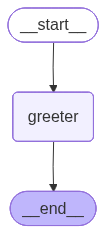

In [16]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [17]:
result = app.invoke({"message":"Bob"})

In [18]:
result["message"]

'HeyBob,how is your day going ? '

second graph 

In [23]:
from typing import TypedDict, List
from langgraph.graph import StateGraph 

In [24]:
class AgentState(TypedDict):
       values :List[int]
       name :str 
       result : str 



In [25]:
def process_values(state:AgentState) -> AgentState:
       """This function handles multiple values."""

       values = state.get('values', [])
       name = state.get('name', 'Unknown')
       return {'result': f"Hello {name}, the sum of your values is {sum(values)}"}

In [26]:
graph=StateGraph(AgentState)
graph.add_node("processor",process_values)

In [26]:
graph=StateGraph(AgentState)
graph.add_node("processor",process_values)
graph.set_entry_point("processor")
graph.set_finish_point("processor")
app=graph.compile()

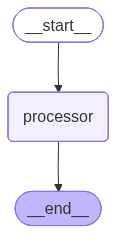

In [33]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [38]:
result=app.invoke({"values": [1, 2, 3], "name": "Alice"})

In [39]:
# Clean fixed processor graph cell
from typing import TypedDict, List
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    values: List[int]
    name: str
    result: str

def process_values(state: AgentState) -> AgentState:
    values = state.get("values", [])
    name = state.get("name", "Unknown")
    return {"result": f"Hello {name}, the sum of your values is {sum(values)}"}

graph = StateGraph(AgentState)
graph.add_node("processor", process_values)
graph.set_entry_point("processor")
graph.set_finish_point("processor")
app = graph.compile()

result = app.invoke({"values": [1, 2, 3], "name": "Alice"})
result

{'values': [1, 2, 3],
 'name': 'Alice',
 'result': 'Hello Alice, the sum of your values is 6'}

In [40]:
print(result["result"])  # Output: Hello Alice, the sum of your values is 6

Hello Alice, the sum of your values is 6


just access results 

graph III

In [42]:
from typing import TypedDict
from langgraph.graph import StateGraph

In [43]:
class AgentState(TypedDict):
       name :str
       age : str 
       final : str 

In [44]:
def first_node(state:AgentState) -> AgentState:
       """ This is the first node of sequence"""


       state['final']=f"Hi, {state['name']}! You are {state['age']} years old."
       return state

def second_node(state:AgentState) -> AgentState:
       """ This is the second node of sequence"""
       state['final'] += " This is the second node."
       return state



In [45]:
graph=StateGraph(AgentState)
graph.add_node("first_node",first_node)
graph.add_node("second_node",second_node)
graph.set_entry_point("first_node")
graph.add_edge("first_node","second_node")
graph.set_finish_point("second_node")
app=graph.compile()


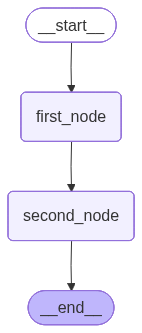

In [46]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))